In [1]:
#importing several python liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load data
df = pd.read_csv("data/data.csv")

In [3]:
# preview data (content of data)
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [4]:
# technical structure of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 334 non-null    int64  
 1   Gender              334 non-null    object 
 2   Protein1            334 non-null    float64
 3   Protein2            334 non-null    float64
 4   Protein3            334 non-null    float64
 5   Protein4            334 non-null    float64
 6   Tumour_Stage        334 non-null    object 
 7   Histology           334 non-null    object 
 8   ER status           334 non-null    object 
 9   PR status           334 non-null    object 
 10  HER2 status         334 non-null    object 
 11  Surgery_type        334 non-null    object 
 12  Date_of_Surgery     334 non-null    object 
 13  Date_of_Last_Visit  317 non-null    object 
 14  Patient_Status      321 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 39.3+ K

In [5]:
# summary
df.describe()

,Age,Protein1,Protein2,Protein3,Protein4
count,334.000000,334.000000,334.000000,334.000000,334.000000
mean,58.886228,-0.029991,0.946896,-0.090204,0.009819
std,12.961212,0.563588,0.911637,0.585175,0.629055
min,29.000000,-2.340900,-0.978730,-1.627400,-2.025500
25%,49.000000,-0.358888,0.362173,-0.513748,-0.377090
50%,58.000000,0.006129,0.992805,-0.173180,0.041768
75%,68.000000,0.343598,1.627900,0.278353,0.425630
max,90.000000,1.593600,3.402200,2.193400,1.629900


In [6]:
#checks data size
df.shape

(334, 15)

In [7]:
# missing value treatment (data cleaning)
df.isnull().sum()

Age                    0
Gender                 0
Protein1               0
Protein2               0
Protein3               0
Protein4               0
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [8]:
#removes missing (NaN) values
#df = df.dropna()

In [9]:
#replace missing (NAN) values
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [12]:
cols=[ 'Protein1', 'Protein2', 'Protein3', 'Protein4' ]

In [13]:
df[cols]=df[cols].replace(0,np.NAN)

In [14]:
df.isnull().sum()

Age                    0
Gender                 0
Protein1               2
Protein2               0
Protein3               0
Protein4               1
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [15]:
df[cols]=df[cols].fillna(df[cols].mean())
df.isnull().sum()

Age                    0
Gender                 0
Protein1               0
Protein2               0
Protein3               0
Protein4               0
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [16]:
df_num=df.select_dtypes(include=np.number)
df.columns

Index(['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4',
       'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status',
       'Surgery_type', 'Date_of_Surgery', 'Date_of_Last_Visit',
       'Patient_Status'],
      dtype='object')

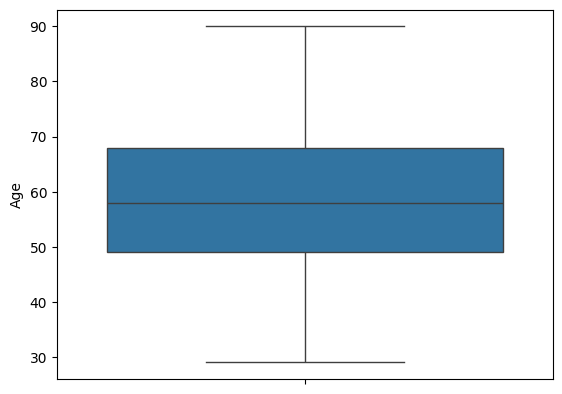

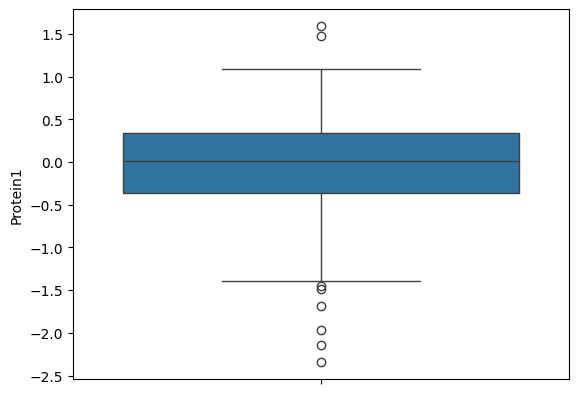

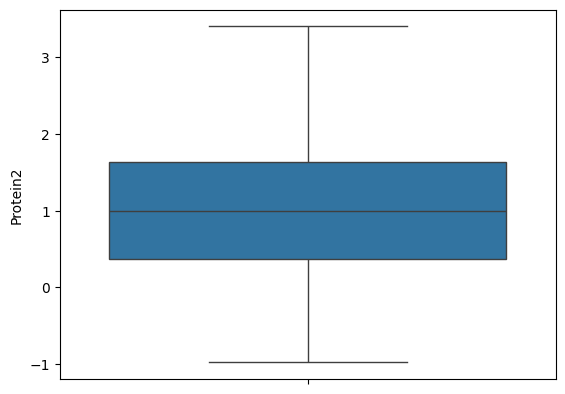

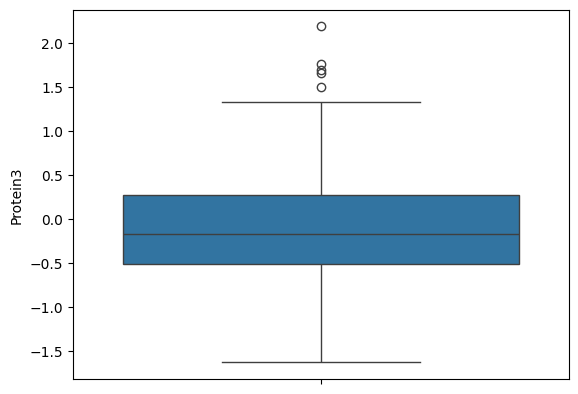

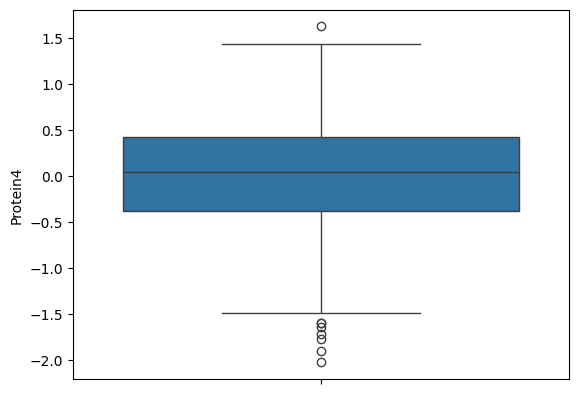

In [17]:
# outlier detection
for i in df_num.columns:
    sns.boxplot(df_num[i])
    plt.show()

In [18]:
# outlier handling
for i in df_num.columns:
    q1=df_num[i].quantile(0.25)
    q3=df_num[i].quantile(0.75)
    iqr=q3-q1
    ub=q3+1.5*iqr
    lb=q1-1.5*iqr
    df_num[i]=np.where(df_num[i]<lb,lb,df_num[i])
    df_num[i]=np.where(df_num[i]>ub,ub,df_num[i])

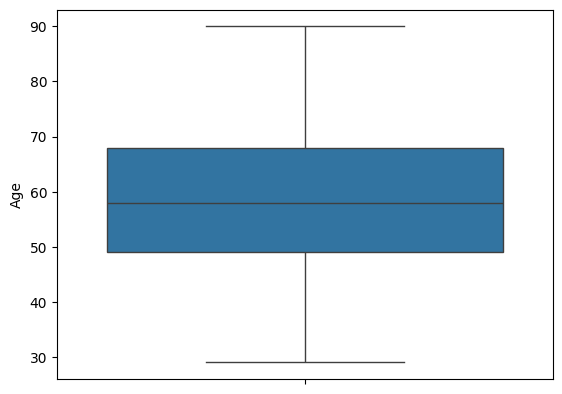

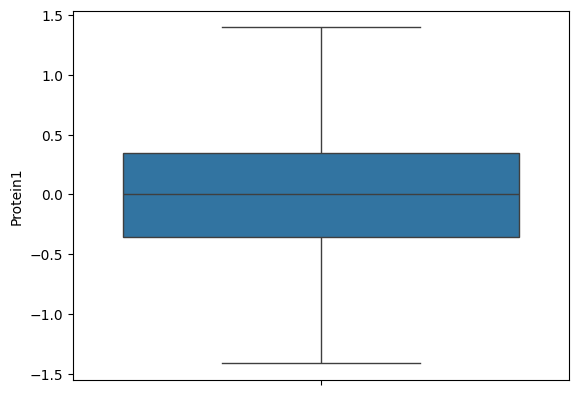

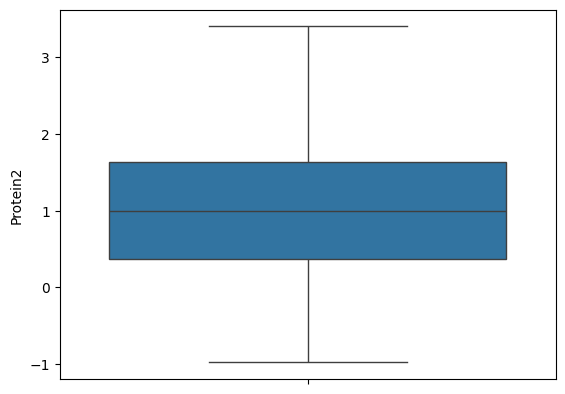

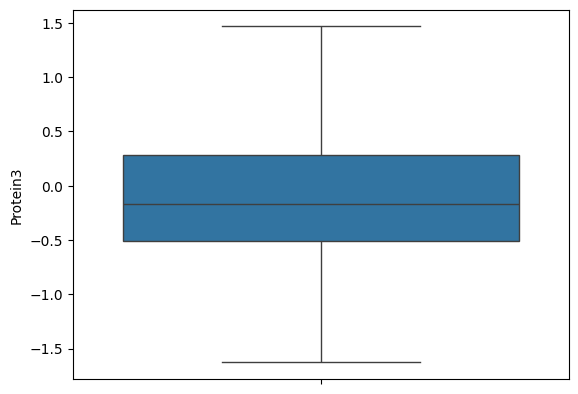

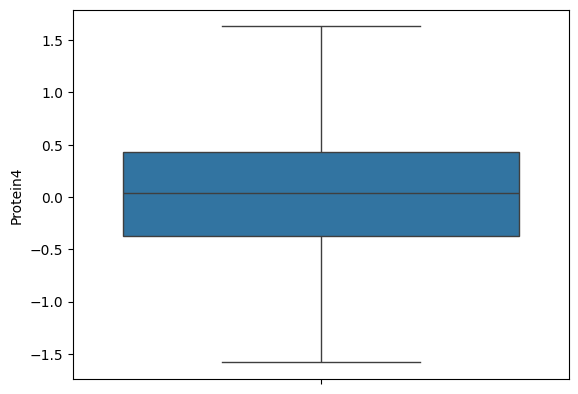

In [19]:
for i in df_num.columns:
    sns.boxplot(df_num[i])
    plt.show()

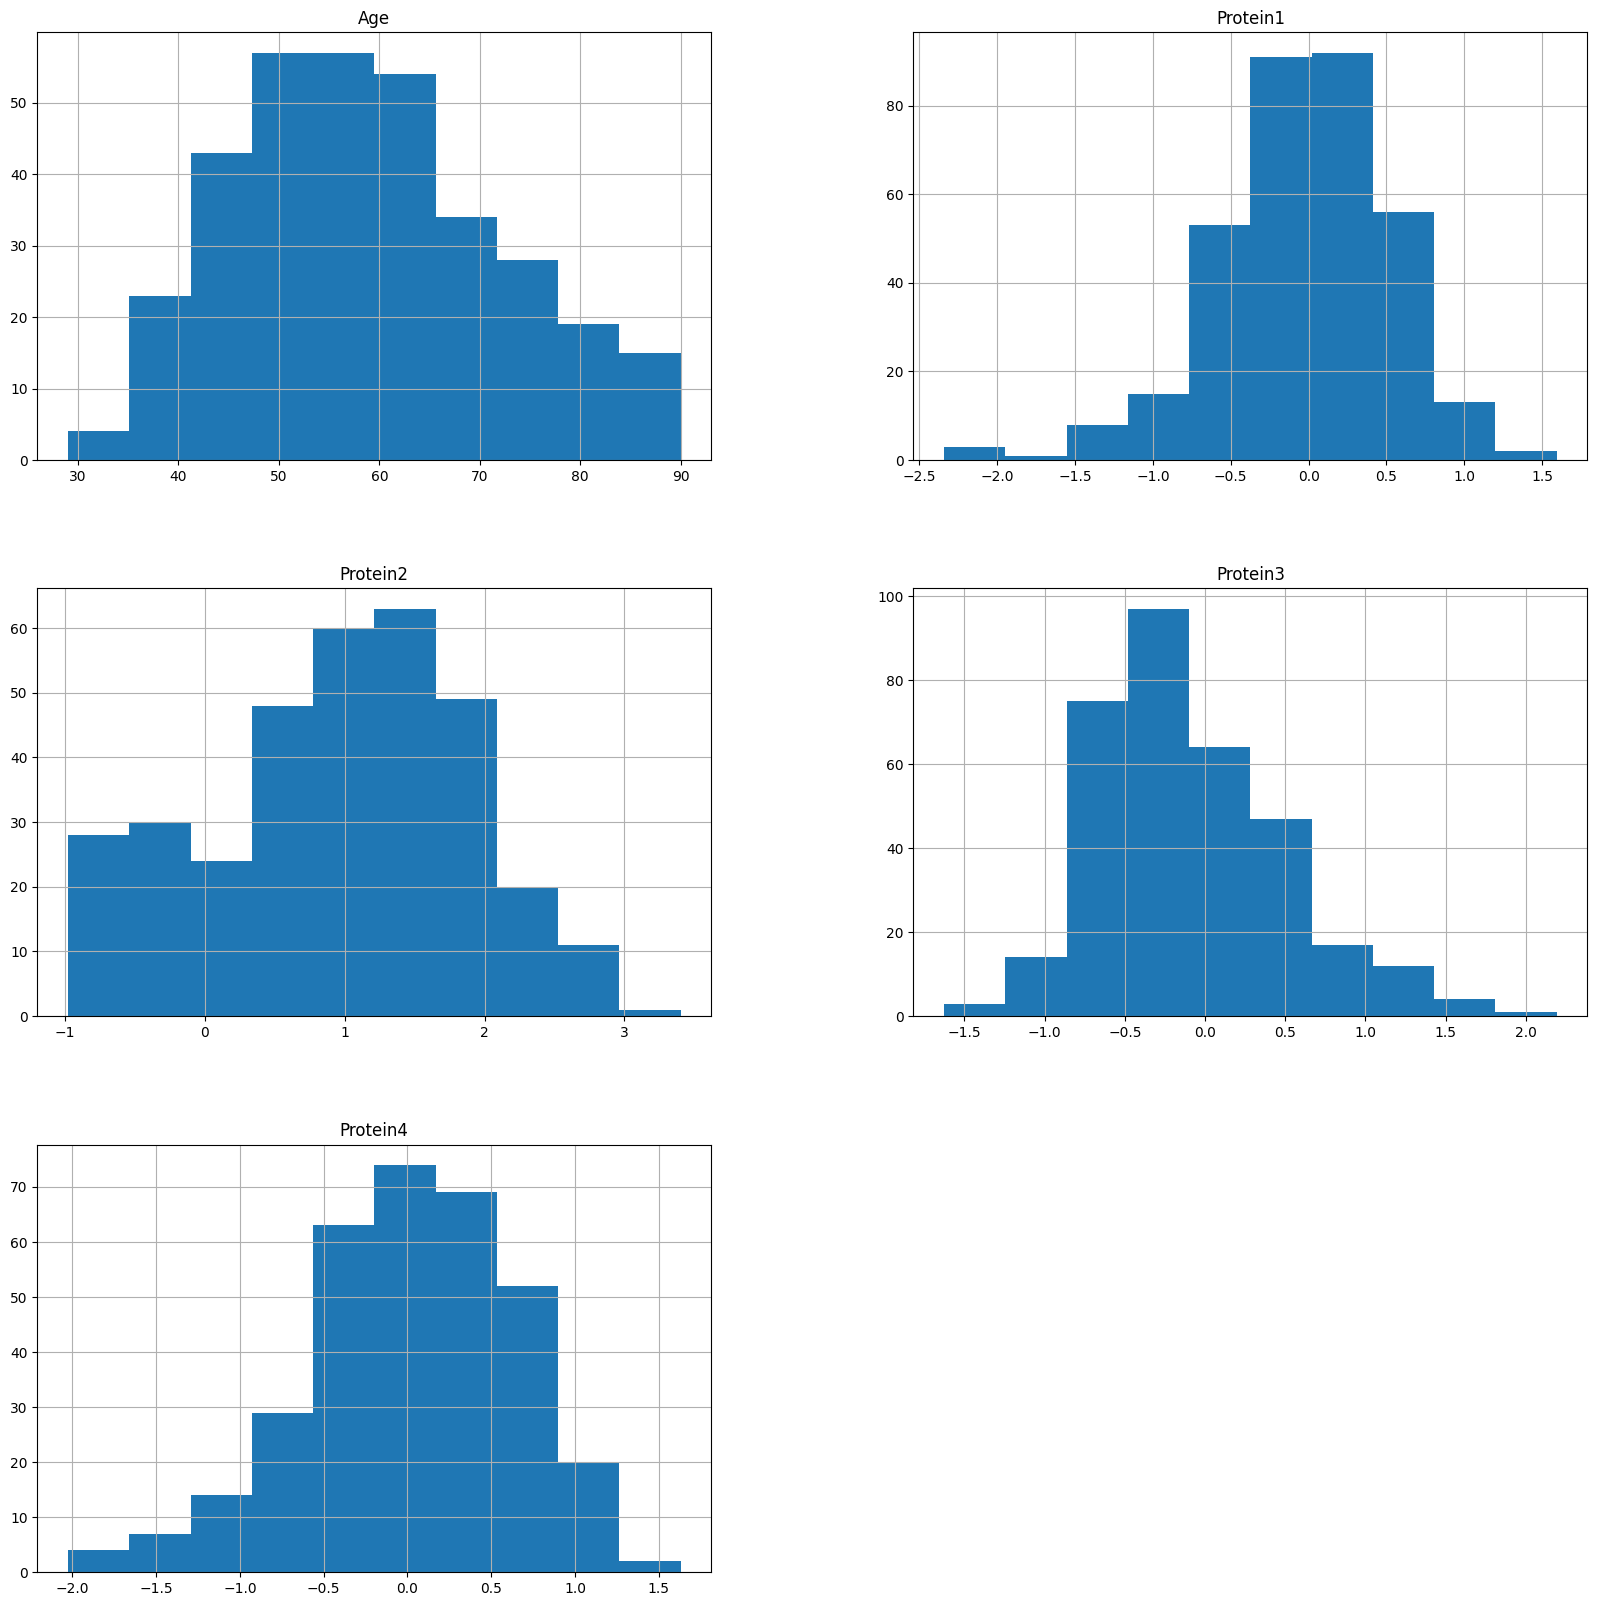

In [20]:
# distribution of data (histogram)
hplot=df.hist(figsize=(20,20))

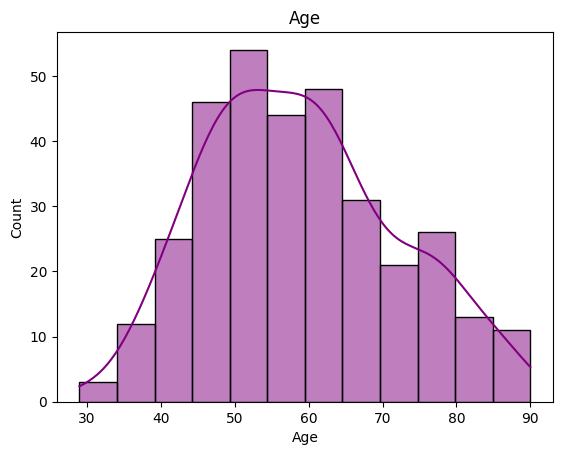

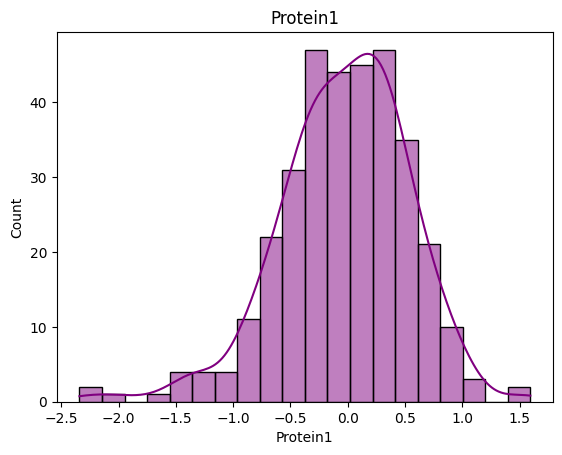

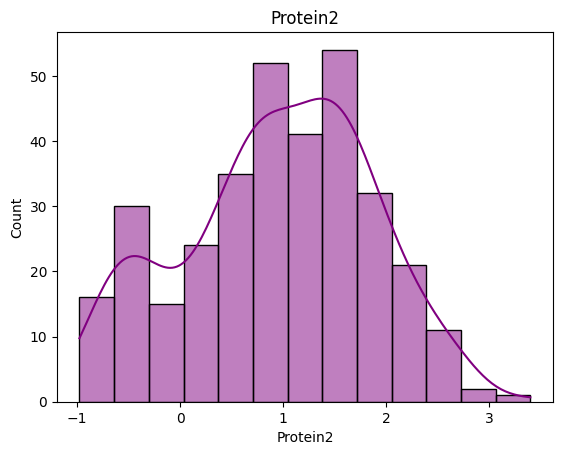

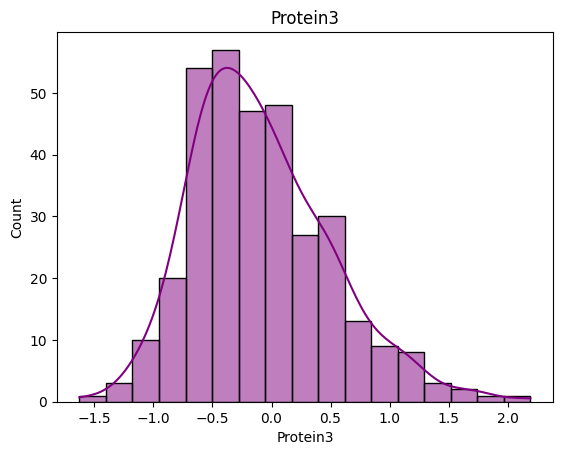

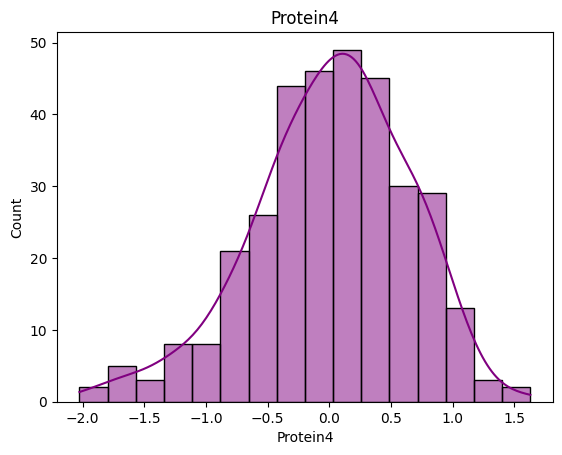

In [21]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True,color='purple')
    plt.title(col)
    plt.show()

In [22]:
# target value
df.Patient_Status.value_counts()

Patient_Status
Alive    255
Dead      66
Name: count, dtype: int64

<Axes: xlabel='Patient_Status'>

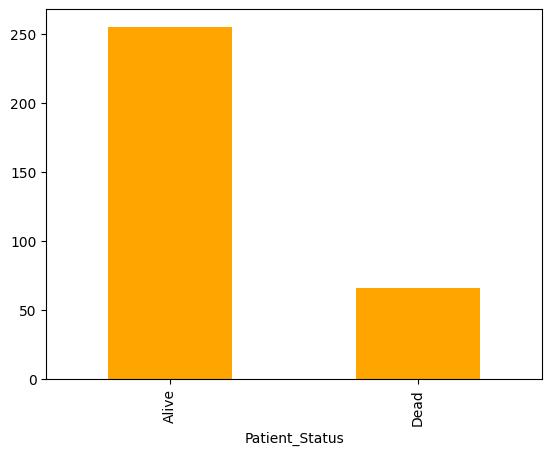

In [23]:
#bar garph
df.Patient_Status.value_counts().plot(kind='bar',color='orange' )

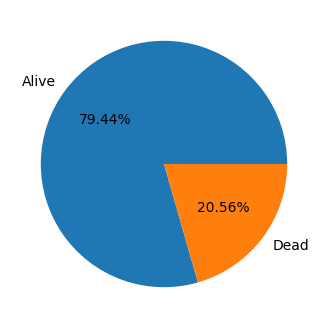

In [24]:
#groupby
plt.figure(figsize=(4,4))
gb = df.groupby('Patient_Status').agg({'Patient_Status':'count'})
plt.pie(gb['Patient_Status'], labels = gb.index, autopct = '%1.2f%%')
plt.show()

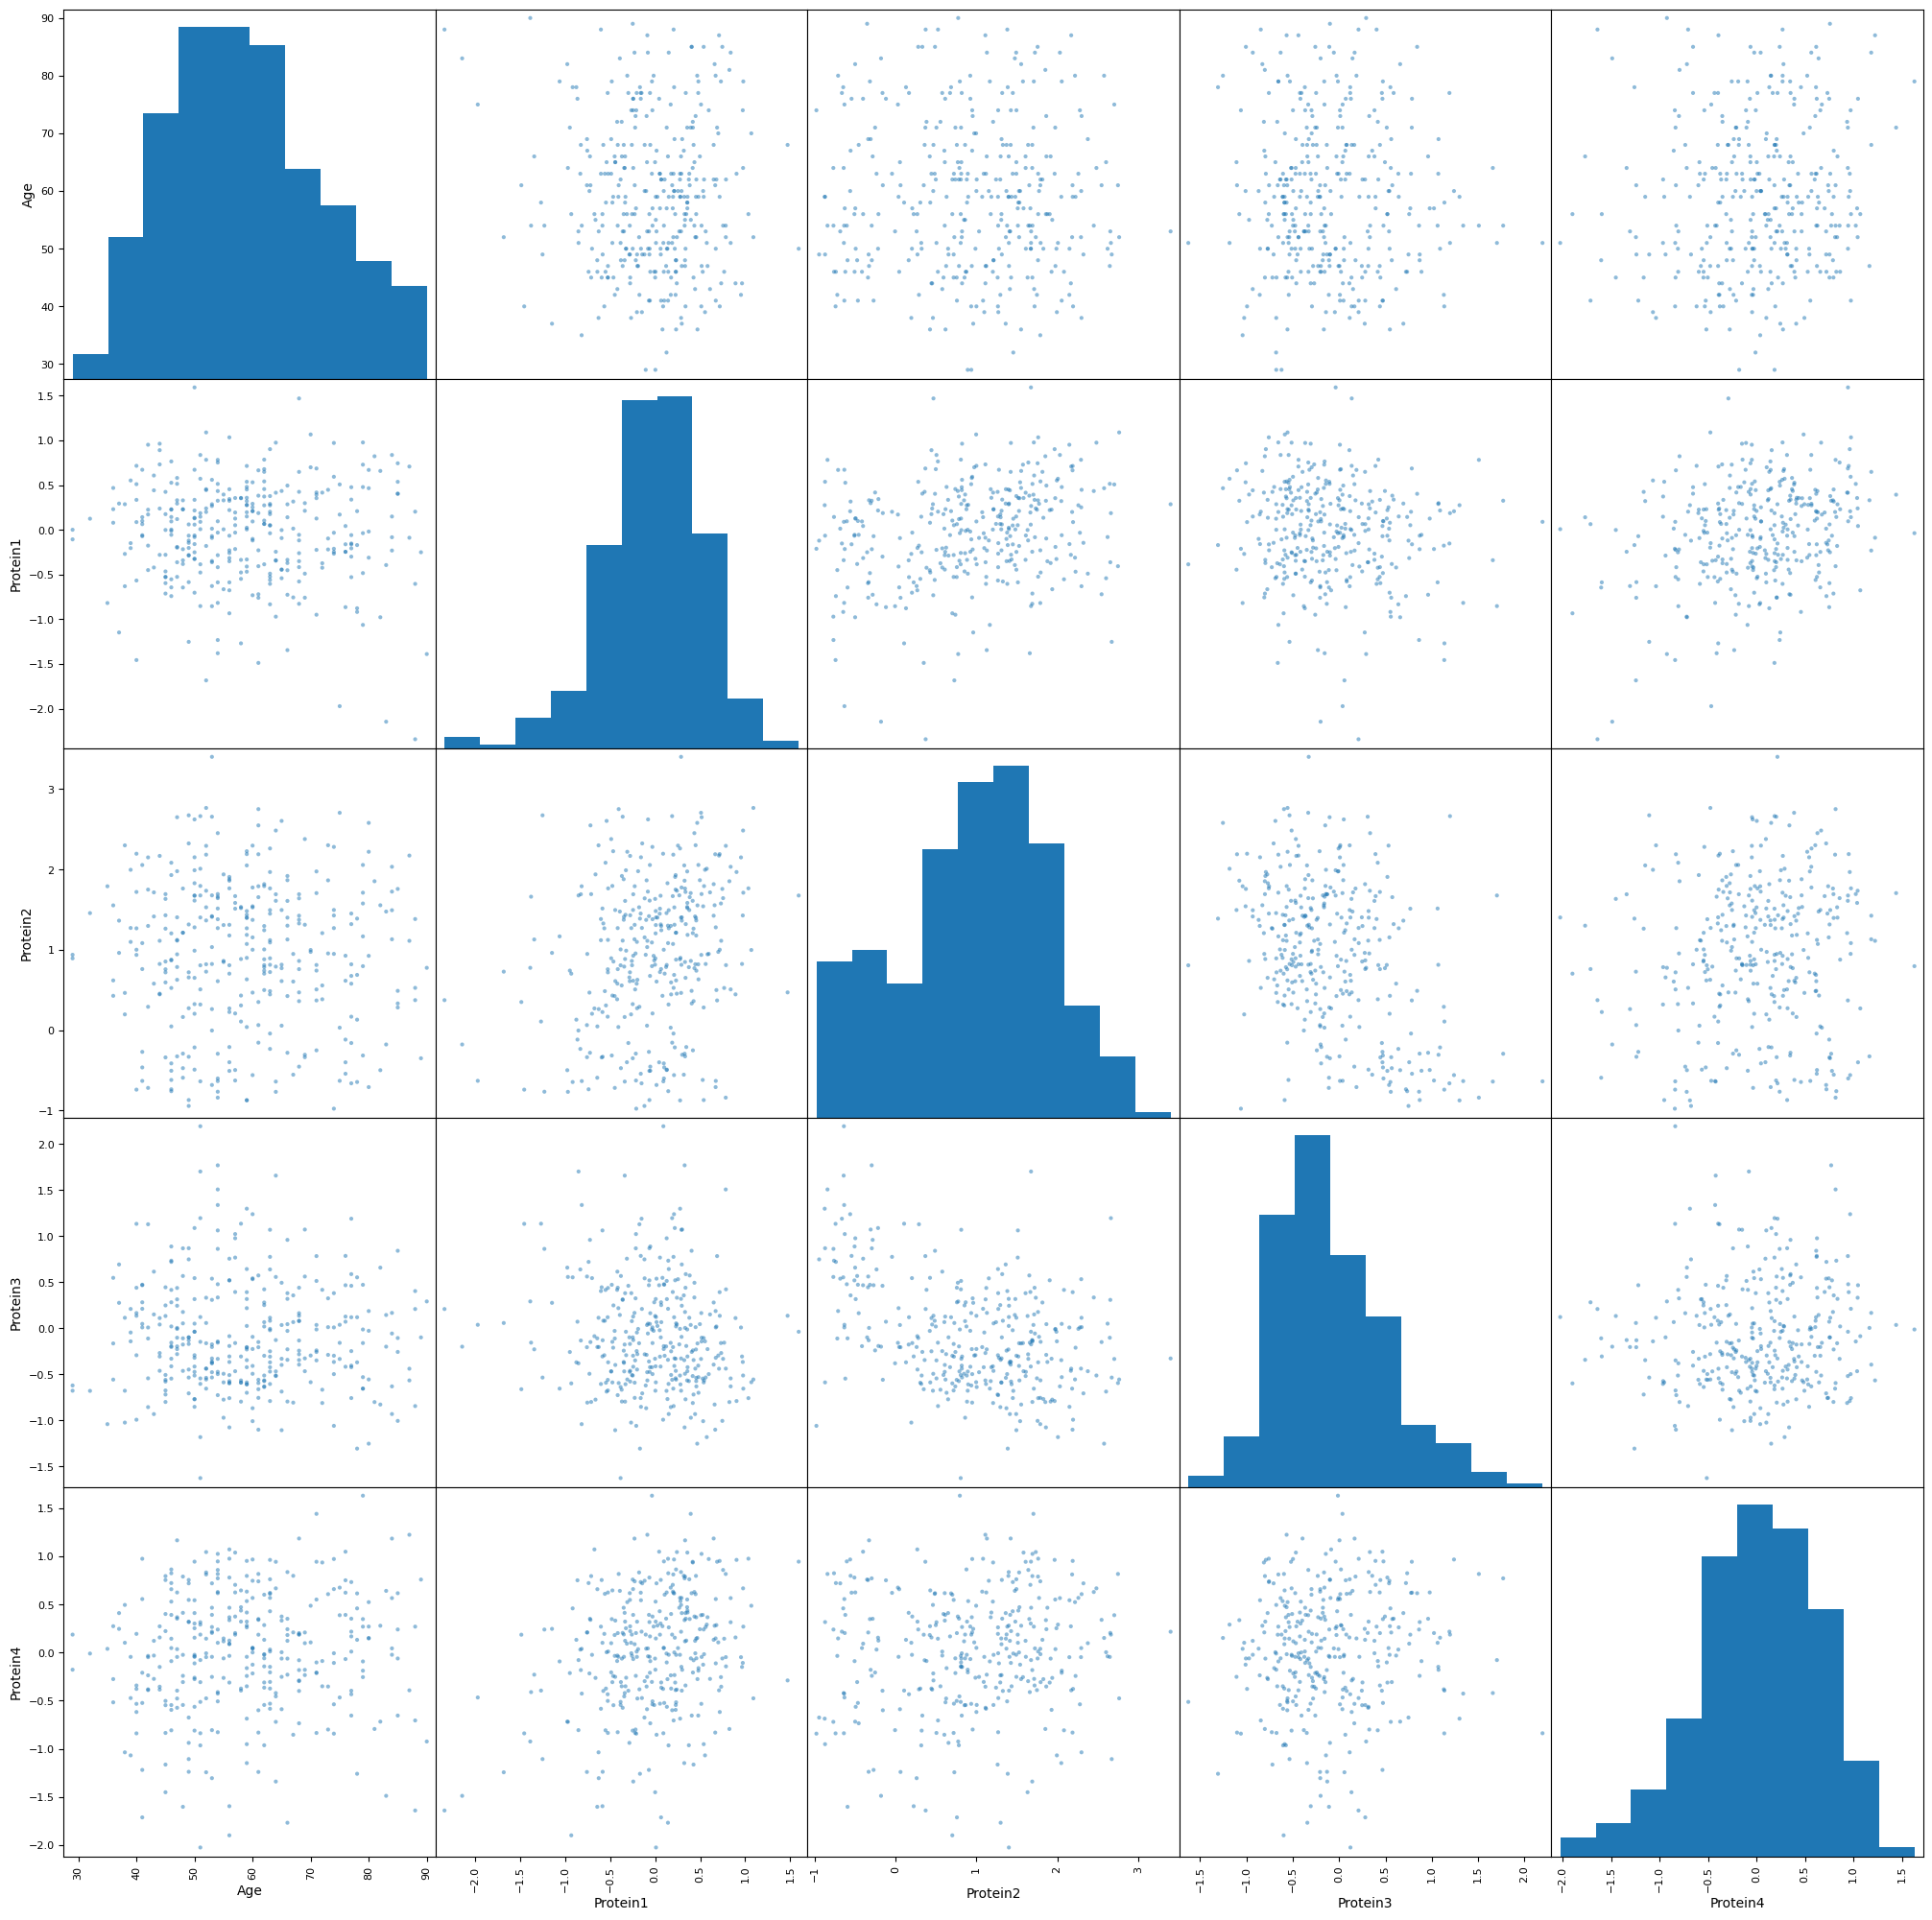

In [25]:
# scatter matrix
from pandas.plotting import scatter_matrix
p = scatter_matrix(df,figsize=(25,25))

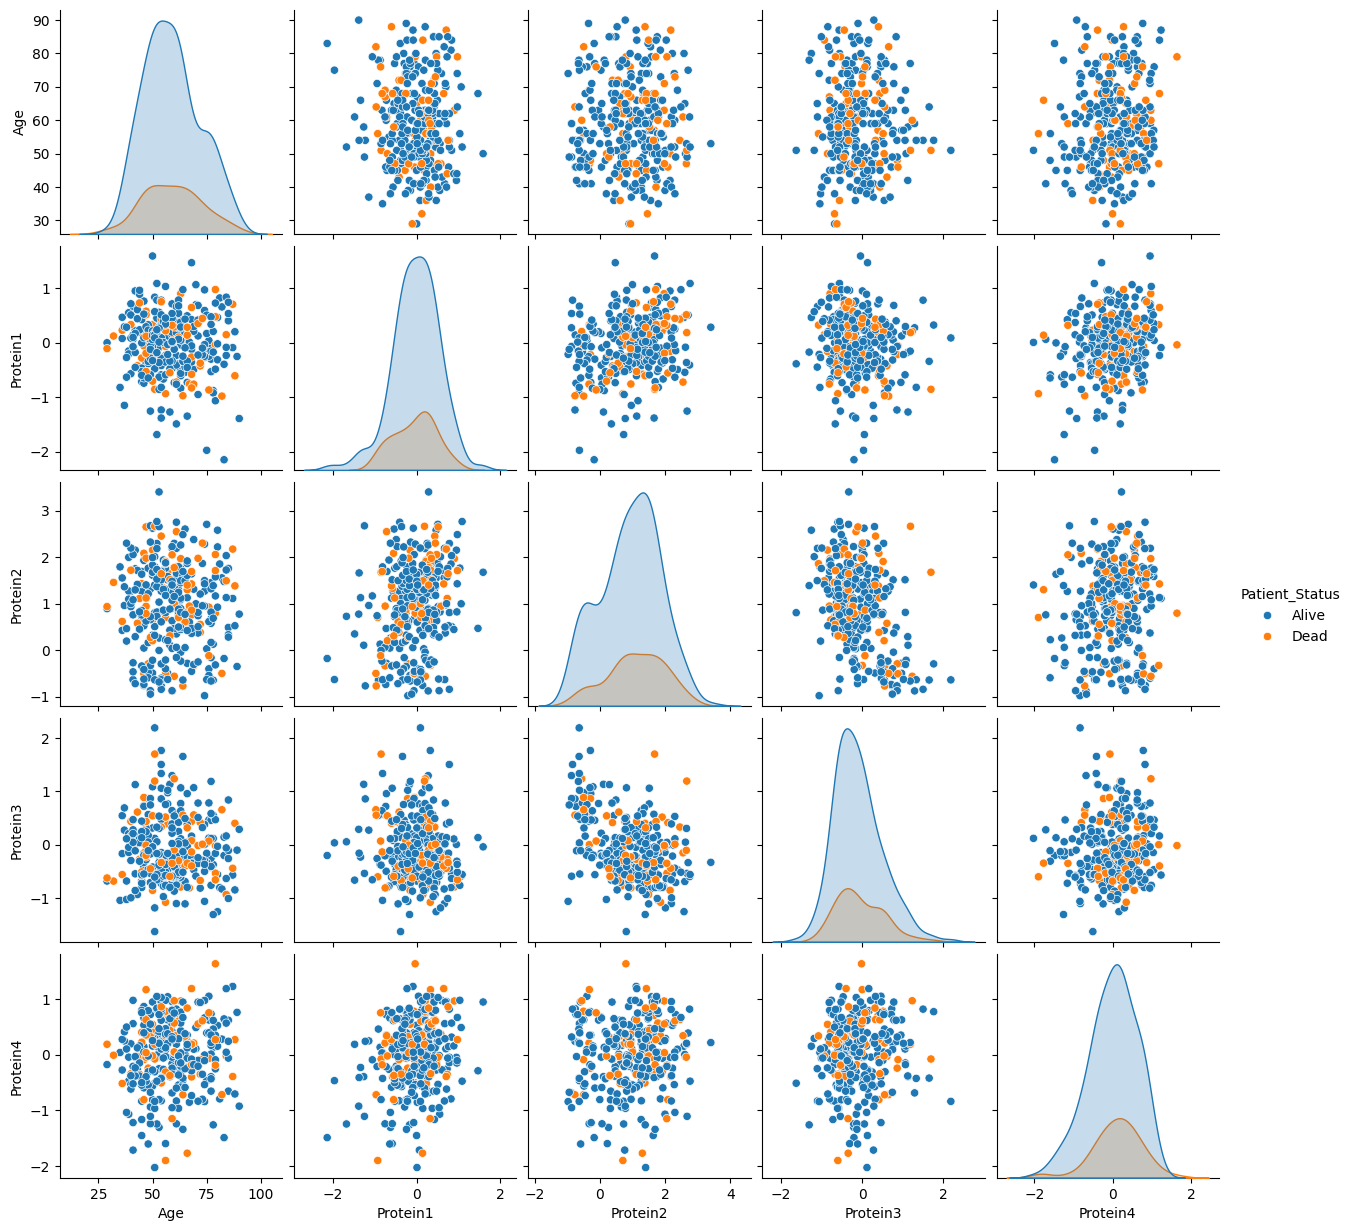

In [26]:
# seaborn pairplot
p = sns.pairplot(df,hue='Patient_Status')

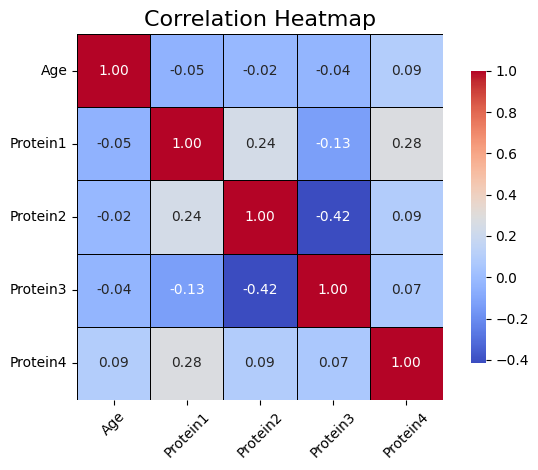

In [27]:
# correlation heatmap
plt.Figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr ,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='black',
    square=True,
    cbar_kws={"shrink":0.8}
)
plt.title("Correlation Heatmap",fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
df_num

,Age,Protein1,Protein2,Protein3,Protein4
0,42.0,0.952560,2.15000,0.007972,-0.048340
1,54.0,-0.030172,1.38020,-0.498030,-0.507320
2,63.0,-0.523030,1.76400,-0.370190,0.010815
3,78.0,-0.876180,0.12943,-0.370380,0.132190
4,42.0,0.226110,1.74910,-0.543970,-0.390210
...,...,...,...,...,...
329,59.0,0.024598,1.40050,0.024751,0.280320
330,41.0,0.100120,-0.46547,0.472370,-0.523870
331,54.0,0.753820,1.64250,-0.332850,0.857860
332,74.0,0.972510,1.42680,-0.366570,-0.107820


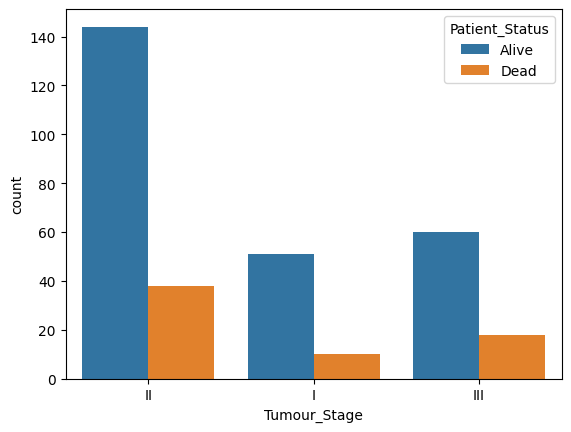

In [29]:
sns.countplot(x='Tumour_Stage', hue='Patient_Status',data=df)
plt.show()

## Modeling moved

Model training and testing have been moved to `model_training_testing_breast_cancer.ipynb`.